EXERCÍCIO 1 - ELITISMO
Menor custo final com elitismo: 269.49
Menor custo final sem elitismo: 262.12
Vezes em que o melhor custo piorou com elitismo: 0
Vezes em que o melhor custo piorou sem elitismo: 2


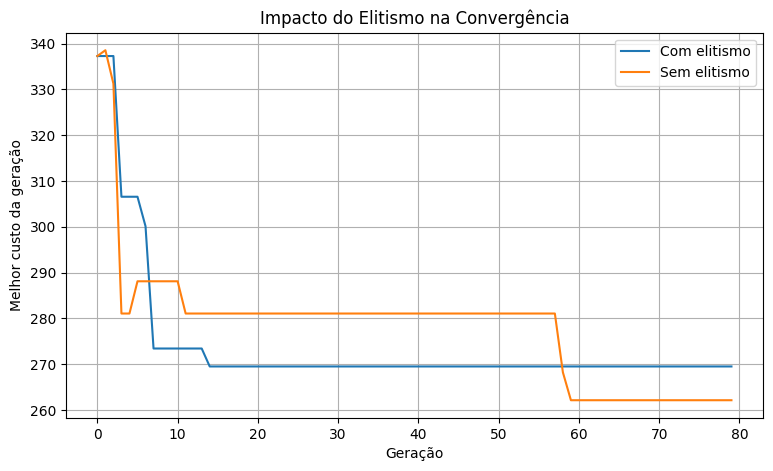

In [3]:
import numpy as np
import matplotlib.pyplot as plt


NUM_NOS = 8
TAM_POP = 40
GERACOES = 80
SEED = 2026


def calcular_custo(rota, matriz):
    dist = 0.0

    for i in range(len(rota) - 1):
        dist += matriz[rota[i], rota[i + 1]]

    return dist + matriz[rota[-1], rota[0]]


def executar_ag(usar_elitismo):
    # A mesma semente é usada nos dois testes para facilitar a comparação.
    np.random.seed(SEED)

    matriz_teste = np.random.uniform(
        10,
        100,
        (NUM_NOS, NUM_NOS)
    )

    populacao = [
        np.random.permutation(NUM_NOS)
        for _ in range(TAM_POP)
    ]

    historico = []

    for _ in range(GERACOES):
        custos = [
            calcular_custo(ind, matriz_teste)
            for ind in populacao
        ]

        melhor_idx = int(np.argmin(custos))
        historico.append(float(custos[melhor_idx]))

        novos = []

        if usar_elitismo:
            novos.append(
                populacao[melhor_idx].copy()
            )

        while len(novos) < TAM_POP:
            i1, i2 = np.random.choice(
                TAM_POP,
                2,
                replace=False
            )

            pai = (
                populacao[i1]
                if custos[i1] < custos[i2]
                else populacao[i2]
            )

            filho = pai.copy()

            if np.random.rand() < 0.3:
                idx1, idx2 = np.random.choice(
                    NUM_NOS,
                    2,
                    replace=False
                )

                filho[idx1], filho[idx2] = (
                    filho[idx2],
                    filho[idx1]
                )

            novos.append(filho)

        populacao = novos

    custos_finais = [
        calcular_custo(ind, matriz_teste)
        for ind in populacao
    ]

    return min(custos_finais), historico


custo_com_elitismo, historico_com = executar_ag(True)
custo_sem_elitismo, historico_sem = executar_ag(False)

pioras_com = sum(
    historico_com[i] > historico_com[i - 1]
    for i in range(1, len(historico_com))
)

pioras_sem = sum(
    historico_sem[i] > historico_sem[i - 1]
    for i in range(1, len(historico_sem))
)


print("=" * 60)
print("EXERCÍCIO 1 - ELITISMO")
print("=" * 60)
print(f"Menor custo final com elitismo: {custo_com_elitismo:.2f}")
print(f"Menor custo final sem elitismo: {custo_sem_elitismo:.2f}")
print(f"Vezes em que o melhor custo piorou com elitismo: {pioras_com}")
print(f"Vezes em que o melhor custo piorou sem elitismo: {pioras_sem}")


plt.figure(figsize=(9, 5))
plt.plot(
    historico_com,
    label="Com elitismo"
)
plt.plot(
    historico_sem,
    label="Sem elitismo"
)

plt.title("Impacto do Elitismo na Convergência")
plt.xlabel("Geração")
plt.ylabel("Melhor custo da geração")
plt.grid(True)
plt.legend()
plt.show()
